# Time of Flight Compensation

This experiment determines the time of flight for a signal to travel from a Qblox output to input. This is used in other experiments to begin data acquisition
at the precise moment the signal reaches the input. O1 and O2 are connected to I1 and I2 respectively of the Qblox QRM module. The time of flight in nanoseconds is printed at the bottom of the notebook. Use this value in other experiments where the time of flight is relevant.

This code is adapted from the Qblox tutorial on conditional playback.

Authors: Noah Stieler, Luke Dyer

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qblox_instruments import Cluster
from qblox_instruments.types import InstrumentType

In [2]:
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
cluster = Cluster("cluster_mm", "192.168.137.2")
moduleQRM = None
moduleQCM = None

modules = [mod for mod in cluster.modules if mod.present()]
for mod in modules:
	print(str(mod) + " type=" + str(mod.module_type) + " is_rf_type=" + str(mod.is_rf_type))

cluster.reset()
cluster.get_system_state()

moduleQRM = modules[1]

<QcmQrm: cluster_mm_module2 of Cluster: cluster_mm> type=QCM is_rf_type=False
<QcmQrm: cluster_mm_module4 of Cluster: cluster_mm> type=QRM is_rf_type=False
<QcmQrm: cluster_mm_module6 of Cluster: cluster_mm> type=QCM is_rf_type=True


In [4]:
waveformLength = 120
t = np.arange(-80, 81, 1)
sigma = 20
waveforms = {
	"zero": {"data": [0.0] * 1024, "index": 0},
	"one": {"data": [1.0] * 1024, "index": 1},
}
acquisitions = {
	"single": {"index": 0, "num_bins": 1}
}

moduleQRM.sequencer0.nco_freq(50e6)	#This sets the modulation frequency
moduleQRM.sequencer0.mod_en_awg(True)
moduleQRM.sequencer0.demod_en_acq(True)
moduleQRM.disconnect_inputs()
moduleQRM.disconnect_outputs()
moduleQRM.sequencer0.connect_sequencer("io0_1")

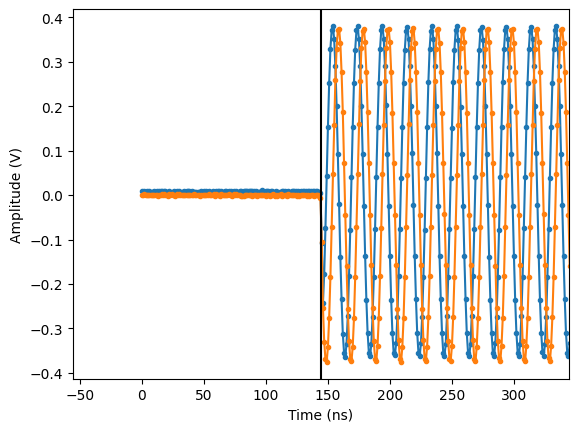

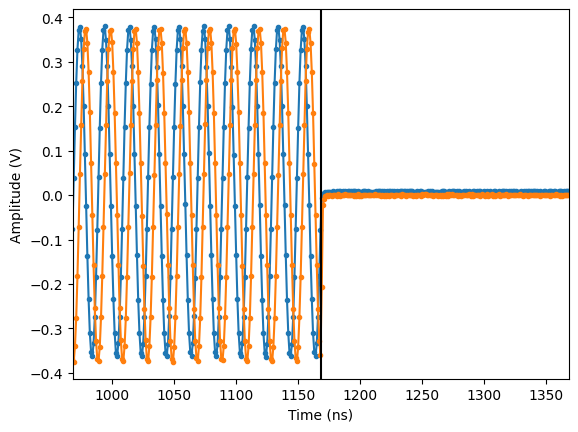

Measured TOF:  144.33333333333334
Rounded TOF:  144


In [5]:
sequenceProgram = """
	play	1,0,4
	acquire	0,0,16384
	stop
"""
sequence = {
	"waveforms": waveforms,
	"weights": {},
	"acquisitions": acquisitions,
	"program": sequenceProgram
}

moduleQRM.sequencer0.sequence(sequence)

moduleQRM.arm_sequencer(0)
moduleQRM.start_sequencer()

moduleQRM.get_acquisition_state(0, 1)
moduleQRM.store_scope_acquisition(0, "single")
acq = moduleQRM.get_acquisitions(0)
p0 = np.array(acq["single"]["acquisition"]["scope"]["path0"]["data"])
p0 = np.array(acq["single"]["acquisition"]["scope"]["path1"]["data"])
#Determine when signal crosses half-max for the first time (ns)
tHalfMax = np.where(np.abs(p0) > np.max(p0)/2.0)[0][0]
#The time it takes for a sine wave to reach its half-max value (ns)
correction = 1 / moduleQRM.sequencer0.nco_freq() * 1e9 / 12

tofMeasured = tHalfMax - correction

r = moduleQRM.get_acquisitions(0)["single"]["acquisition"]["scope"]
plt.plot(r["path0"]["data"], ".-")
plt.plot(r["path1"]["data"], ".-")
plt.axvline(tofMeasured, c="k")
plt.xlim(
	tofMeasured - 10 / moduleQRM.sequencer0.nco_freq() * 1e9,
	tofMeasured + 10 / moduleQRM.sequencer0.nco_freq() * 1e9,
)
plt.ylabel("Amplitude (V)")
plt.xlabel("Time (ns)")
plt.show()

plt.plot(r["path0"]["data"], ".-")
plt.plot(r["path1"]["data"], ".-")
plt.axvline(1024 + tofMeasured, c="k")
plt.xlim(
	1024 + tofMeasured - 10 / moduleQRM.sequencer0.nco_freq() * 1e9,
	1024 + tofMeasured + 10 / moduleQRM.sequencer0.nco_freq() * 1e9,
)
plt.ylabel("Amplitude (V)")
plt.xlabel("Time (ns)")
plt.show()

tof = int(tofMeasured)
print("Measured TOF: ", tofMeasured)
print("Rounded TOF: ", tof)